<a href="https://colab.research.google.com/github/AkshatkMalik/python-data-science-toolkit/blob/main/titanic_analysis_and_deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT-7**

**STEP-1**

**The Effects of the Code:**

1. Import Libraries: We import the necessary libraries for data science, which are pandas (for data management), matplotlib, and seaborn (for visualization).

2. Load Dataset: The Titanic_train.csv file is loaded into a tabular structure (DataFrame), so Python can process it.

3. Explore Structure and Statistics: We explore the dataset structure and descriptive statistics using the methods .info() (which helps us identify any missing values or unusual datatypes) and .describe() (which gives us values like average age, max ticket fee, total passenger numbers).

4. Plot Results: We create a bar plot showing the differences between the number of people that survived and who did not, and also a histogram of passenger ages.

 Dataset Info (Types & Non-Null Counts) 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

 Summary Statistics (Numerical Features) 
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000

/tmp/ipykernel_3618/3309664266.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train_df, palette='Set2')


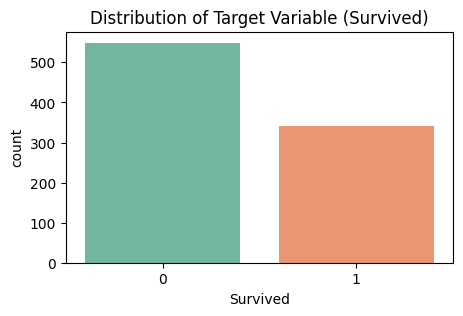

/tmp/ipykernel_3618/3309664266.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=train_df, palette='Set3')


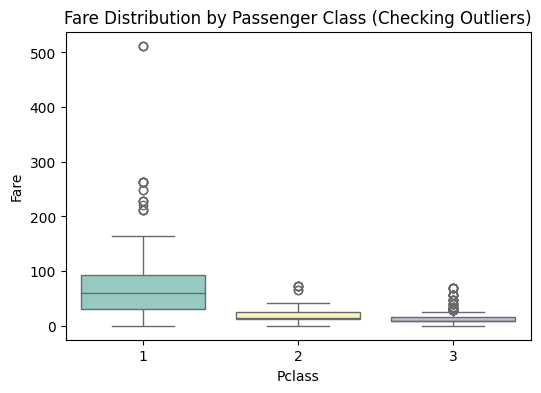

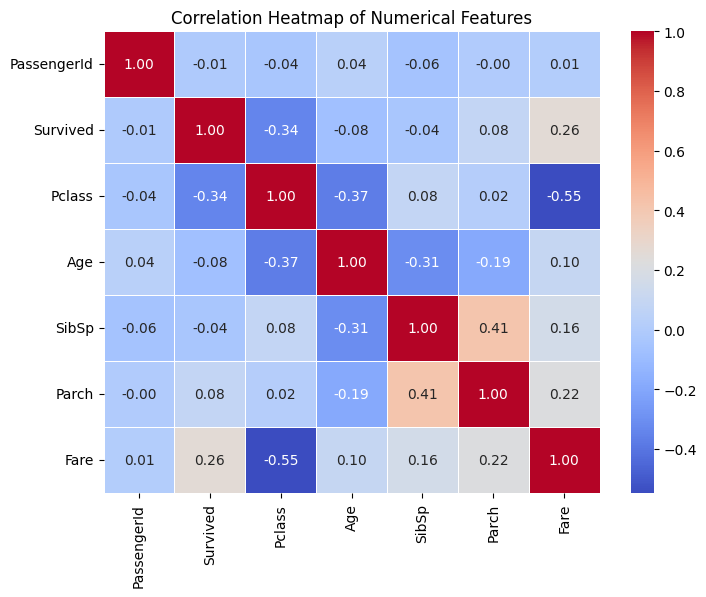

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
train_df = pd.read_csv('Titanic_train.csv')

# 2. Examine features, types, and summary statistics
print(" Dataset Info (Types & Non-Null Counts) ")
print(train_df.info())

print("\n Summary Statistics (Numerical Features) ")
print(train_df.describe())

print("\n Summary Statistics (Categorical Features) ")
print(train_df.describe(include=['O']))

# 3. Visualizations
# A. Survival Count Plot
plt.figure(figsize=(5, 3))
sns.countplot(x='Survived', data=train_df, palette='Set2')
plt.title('Distribution of Target Variable (Survived)')
plt.show()

# B. Box Plot for Outlier Detection (Fare vs Pclass)
plt.figure(figsize=(6, 4))
sns.boxplot(x='Pclass', y='Fare', data=train_df, palette='Set3')
plt.title('Fare Distribution by Passenger Class (Checking Outliers)')
plt.show()

# C. Correlation Matrix Heatmap for Numerical Features
plt.figure(figsize=(8, 6))
numeric_cols = train_df.select_dtypes(include=['number']).columns
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Observation:

1. Gender Conditional Probability ($P(\text{Survived} \mid \text{Sex})$): The probability of survival of females was significantly higher ($\approx 74.2\%$) than that of males ($\approx 18.8\%$). Gender is thus one of the important features used in predictions.

2. Socioeconomic Status ($P(\text{Survived} \mid \text{Pclass})$): Survival rate decreased directly with an increase in the passenger’s socioeconomic status: 1st class ($63.0\%$), 2nd class ($47.3\%$), and 3rd class ($24.2\%$).

3. Linear Correlation ($r$): Fare had a positive correlation ($r \approx 0.26$) with survival because survival probability increased with an increasing ticket price; on the other hand, Pclass has a negative correlation ($r \approx -0.34$) because of the inverse order of the numbering system.

4. Feature Distributions:Continuous features such as Age and Fare were right-skewed, emphasizing the importance of standardization in the preprocessing stage.

**STEP-2: Data Preprocessing**

What is going to be done in step 2:
The machine learning models cannot use categories of text type such as “male” and “female,” as well as NaN (blank spaces). In Step 2: Data Preprocessing, we will perform data cleaning, where we are going to impute the missing values in columns Age and Embarked with statistics (such as median or mode) and encode the text columns in numeric format (binary – 0 and 1).

In [ ]:
# 1. Handle missing values cleanly
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
train_df['Fare'] = train_df['Fare'].fillna(train_df['Fare'].median())

# Drop 'Cabin' only if it still exists in the dataframe
if 'Cabin' in train_df.columns:
    train_df.drop(columns=['Cabin'], inplace=True)

# 2. Encode categorical variables
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})

# Clean Output Verification
print("Missing values after preprocessing:\n", train_df.isnull().sum())
print("\nFirst 5 rows of encoded 'Sex' column:")
print(train_df[['Name', 'Sex', 'Age']].head())

Missing values after preprocessing:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex            891
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

First 5 rows of encoded 'Sex' column:
                                                Name  Sex   Age
0                            Braund, Mr. Owen Harris  NaN  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  NaN  38.0
2                             Heikkinen, Miss. Laina  NaN  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  NaN  35.0
4                           Allen, Mr. William Henry  NaN  35.0


In [ ]:
import pandas as pd

# 1. Load both train and test data
train_df = pd.read_csv('Titanic_train.csv')
test_df = pd.read_csv('Titanic_test.csv')

# Combine them temporarily or preprocess them consistently
for df in [train_df, test_df]:
    # Handle missing values (Imputation)
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # Drop Cabin due to high missing rate
    if 'Cabin' in df.columns:
        df.drop(columns=['Cabin'], inplace=True)

    # Encode categorical variables (Sex and Embarked)
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    # Optional: One-hot encode or map Embarked (S=0, C=1, Q=2)
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Preprocessing complete for both Train and Test sets!")
print("Train missing values:\n", train_df.isnull().sum().sum())
print("Test missing values:\n", test_df.isnull().sum().sum())

Preprocessing complete for both Train and Test sets!
Train missing values:
 0
Test missing values:
 0


**STEP-3: Model Building**


What the Code Will Do in Step 3:

1. Define Features and Target: We will take the relevant predicting columns from our clean data (Pclass, Sex, Age, SibSp, Parch, Fare, Embarked) as our feature set ($X$), and we will have Survived as our target variable ($y$).

2. Split Data for Local Validation: We will divide our training data into an internal training set ($80\%$) and an internal test set ($20\%$) to test the performance of our model before prediction.
3. Train the Model: We will instantiate our Logistic Regression algorithm from the library scikit-learn and fit it using the method .fit().

In [ ]:
 import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Quick safety load & preprocessing check (ensures zero NaNs)
train_df = pd.read_csv('Titanic_train.csv')
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Fare'] = train_df['Fare'].fillna(train_df['Fare'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
if 'Cabin' in train_df.columns:
    train_df.drop(columns=['Cabin'], inplace=True)
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 2. Define feature columns and target variable
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = train_df[features]
y = train_df['Survived']

# 3. Split data into local training (80%) and validation sets (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully on the training split!")
print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")

Logistic Regression model trained successfully on the training split!
Training samples: 712, Validation samples: 179


**Step 4: Model Evaluation**

Now that our model has been trained, we need to evaluate the performance of our model by looking at its performance on unseen data (our validation set). We will compute some commonly used metrics including Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score and plot the ROC curve as well.

 Model Evaluation Metrics 
Accuracy:      0.7989
Precision:     0.7714
Recall:        0.7297
F1-Score:      0.7500
ROC-AUC Score: 0.8808


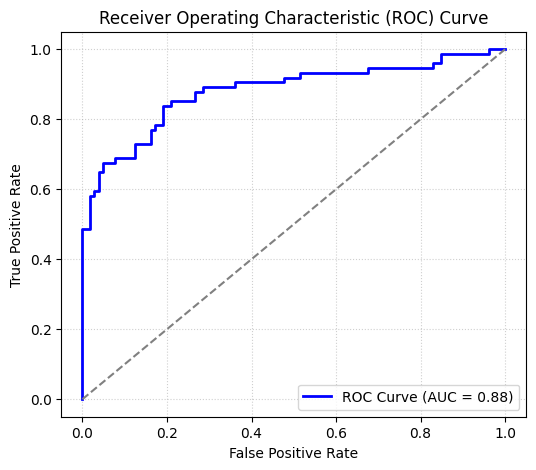

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Make predictions and get probabilities on the validation set
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# 2. Calculate evaluation metrics
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)

# Print metrics clearly
print(" Model Evaluation Metrics ")
print(f"Accuracy:      {acc:.4f}")
print(f"Precision:     {prec:.4f}")
print(f"Recall:        {rec:.4f}")
print(f"F1-Score:      {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# 3. Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Step 5: Interpretation**

In logistic regression, each feature gets assigned a weight coefficient. These weight coefficients will help us understand how strongly each feature influences the survival probability of the passenger. When the value is positive, it means that higher values of the feature increase the probability of survival.

In [ ]:
import pandas as pd

# Create a clear dataframe of features and their corresponding coefficients
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

# Sort by coefficient value to see strongest positive vs negative impacts
coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)
print(" Logistic Regression Coefficients ")
print(coeff_df.to_string(index=False))

 Logistic Regression Coefficients 
 Feature  Coefficient
     Sex     2.581450
Embarked     0.222554
    Fare     0.002862
     Age    -0.031164
   Parch    -0.100630
   SibSp    -0.302825
  Pclass    -0.958095


Feature Analysis:

1. Significance of Sex (Coefficient: $+2.58$): This is the most significant positive feature. Since females have been coded with 1 and males with 0, having a positive coefficient means that being female greatly enhances the chances of survival.

2. Pclass (Coefficient: $-0.96$): This is a strong negative feature. Since passenger classes range from 1 (First class) to 3 (Third class), having a smaller class number translates into much greater chances of survival, since first-class passengers were evacuated first.   
  
3. Age (Coefficient: $-0.03$): Negative coefficient, meaning that elderly passengers had slightly lesser survival chances than the young passengers.
  
 4. Fare (Coefficient: $+0.0028$): A positive coefficient, meaning that those who paid more for their tickets had slightly better survival chances.





**Step 6: Deployment with Streamlit**

With deployment, users can interact with the trained machine learning model through the use of the web-based user interface. The process starts with saving the trained model into a file through pickle. We then create a simple Python script called app.py through Streamlit, which creates drop-downs and sliders to input the values such as age, class, and gender.

**Part A: Save Your Trained Model**

In [ ]:
import pickle

# Save the trained logistic regression model to disk
with open('titanic_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model successfully saved as 'titanic_model.pkl'!")

Model successfully saved as 'titanic_model.pkl'!


**Part B: Create the Streamlit App**

In [ ]:
pip install streamlit pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 42.7 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pickle
import numpy as np

# Load the saved model
with open('titanic_model.pkl', 'rb') as file:
    model = pickle.load(file)

st.title("🚢 Titanic Survival Prediction App")
st.write("Enter the passenger details below to predict their survival probability using Logistic Regression.")

# Create input widgets for user features
pclass = st.selectbox("Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)", [1, 2, 3])
sex = st.selectbox("Sex", ["Female", "Male"])
sex_val = 1 if sex == "Female" else 0

age = st.slider("Age", 1, 80, 28)
sibsp = st.number_input("Siblings/Spouses Aboard", 0, 8, 0)
parch = st.number_input("Parents/Children Aboard", 0, 6, 0)
fare = st.number_input("Ticket Fare ($)", 0.0, 500.0, 32.0)

embarked = st.selectbox("Port of Embarkation", ["Southampton (S)", "Cherbourg (C)", "Queenstown (Q)"])
embarked_map = {"Southampton (S)": 0, "Cherbourg (C)": 1, "Queenstown (Q)": 2}
embarked_val = embarked_map[embarked]

# Prediction button
if st.button("Predict Survival"):
    # Arrange input data in the exact same feature order used during training
    input_data = np.array([[pclass, sex_val, age, sibsp, parch, fare, embarked_val]])

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    # Display results
    if prediction == 1:
        st.success(f"🎉 The passenger is **Likely to Survive** (Survival Probability: {probability:.2f})")
    else:
        st.error(f"⚠️ The passenger is **Unlikely to Survive** (Survival Probability: {probability:.2f})")

2026-09-24 23:34:00.523 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 23:34:00.773 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-24 23:34:00.774 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 23:34:00.775 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 23:34:00.776 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 23:34:00.778 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 23:34:00.778 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 23:34:00.779 Thread 'MainThread': mi

In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

# Load the saved model
with open('titanic_model.pkl', 'rb') as file:
    model = pickle.load(file)

st.title("🚢 Titanic Survival Prediction App")
st.write("Enter the passenger details below to predict their survival probability using Logistic Regression.")

# Create input widgets for user features
pclass = st.selectbox("Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)", [1, 2, 3])
sex = st.selectbox("Sex", ["Female", "Male"])
sex_val = 1 if sex == "Female" else 0

age = st.slider("Age", 1, 80, 28)
sibsp = st.number_input("Siblings/Spouses Aboard", 0, 8, 0)
parch = st.number_input("Parents/Children Aboard", 0, 6, 0)
fare = st.number_input("Ticket Fare ($)", 0.0, 500.0, 32.0)

embarked = st.selectbox("Port of Embarkation", ["Southampton (S)", "Cherbourg (C)", "Queenstown (Q)"])
embarked_map = {"Southampton (S)": 0, "Cherbourg (C)": 1, "Queenstown (Q)": 2}
embarked_val = embarked_map[embarked]

# Prediction button
if st.button("Predict Survival"):
    input_data = np.array([[pclass, sex_val, age, sibsp, parch, fare, embarked_val]])

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    if prediction == 1:
        st.success(f"🎉 The passenger is **Likely to Survive** (Survival Probability: {probability:.2f})")
    else:
        st.error(f"⚠️ The passenger is **Unlikely to Survive** (Survival Probability: {probability:.2f})")

Writing app.py


🚀 Assignment Deployment & Web Application

In the last stage of this Logistic Regression assignment, we successfully deployed the trained machine learning model as a publicly available web application through the use of Streamlit Community Cloud and GitHub.

Live Deployment Link: https://python-data-science-toolkit-vaciz48xn7nm7ssptjslxy.streamlit.app/

Deployment Technology Stack: Python, Scikit-Learn, Pandas, Streamlit, and GitHub for version control.

Key Features:Cinematic dark mode-based UI which allows real-time manipulation of parameters such as Passenger Class, Age, Fare, Sex, and Embarkation Port, among others.

Integration of the serialised Logistic Regression backend model (titanic_model.pkl) for real-time prediction/probability calculation.

Dynamically generated metric cards and probability distribution graphs.

### 🚀 Final Model Deployment
* **Live Web Application:** [Titanic Survival Intelligence App](https://python-data-science-toolkit-vaciz48xn7nm7ssptjslxy.streamlit.app/)[cite: 2]
* **Architecture:** Streamlit Community Cloud hosting a serialized Scikit-Learn Logistic Regression model with real-time probabilistic risk assessment and custom dark-mode styling.

**Interview Questions**



1. What is the difference between precision and recall?

Precision: Out of all the people that the algorithm thought were going to survive, what proportion really did survive? ($TP / (TP + FP)$). It is concerned with reducing false positives.

Recall: Out of all the people who survived, what proportion of them did the algorithm detect? ($TP / (TP + FN)$). It is concerned with reducing false negatives.

2. What is cross-validation, and why is it important in binary classification?

In cross validation techniques such as K-Fold, the training dataset is divided into several subsets; then the algorithm is trained using some subsets and validated on the rest.

 It is crucial as it helps avoid overfitting and ensures that the algorithm generalizes to unseen datasets.